# JPS (Jump Point Search): A Self-Learning Demo

## Why JPS (Jump Point Search)?

JPS (Jump Point Search) is a speed-up technique for A* on uniform-cost grids.
It skips many redundant intermediate cells and keeps only important jump points.

In this notebook, you will:

1. Build a uniform-cost occupancy grid.
2. Run standard A* as a baseline.
3. Run a learning-oriented JPS-style search.
4. Compare expansions and path shape.

## JPS Method Essentials

- **Pruning**: remove symmetric successor expansions.
- **Jumping**: move in a direction until a meaningful point is found.
- **Jump point**: a state where direction decisions matter (goal, forced neighbor, or branch point).

Note: This notebook uses a compact learning implementation for intuition.

## 1) Helper Functions

In [1]:
%matplotlib inline
from heapq import heappop, heappush
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

Point = Tuple[int, int]


def manhattan(a: Point, b: Point) -> float:
    return float(abs(a[0] - b[0]) + abs(a[1] - b[1]))


def neighbors4(cell: Point, shape: Tuple[int, int]) -> List[Point]:
    r, c = cell
    rows, cols = shape
    out: List[Point] = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols:
            out.append((nr, nc))
    return out


def a_star_grid(grid: np.ndarray, start: Point, goal: Point) -> Tuple[Optional[List[Point]], int]:
    if grid[start] == 1 or grid[goal] == 1:
        return None, 0

    g: Dict[Point, float] = {start: 0.0}
    parent: Dict[Point, Optional[Point]] = {start: None}
    heap: List[Tuple[float, float, Point]] = [(manhattan(start, goal), 0.0, start)]
    expansions = 0

    while heap:
        _, cur_cost, cur = heappop(heap)
        if cur == goal:
            break
        if cur_cost > g.get(cur, float('inf')):
            continue

        expansions += 1
        for nxt in neighbors4(cur, grid.shape):
            if grid[nxt] == 1:
                continue
            new_cost = cur_cost + 1.0
            if new_cost < g.get(nxt, float('inf')):
                g[nxt] = new_cost
                parent[nxt] = cur
                heappush(heap, (new_cost + manhattan(nxt, goal), new_cost, nxt))

    if goal not in parent:
        return None, expansions

    path: List[Point] = []
    cur: Optional[Point] = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, expansions


def jump_until_stop(grid: np.ndarray, cur: Point, dr: int, dc: int, goal: Point) -> Optional[Point]:
    rows, cols = grid.shape
    r, c = cur

    while True:
        r += dr
        c += dc
        if not (0 <= r < rows and 0 <= c < cols):
            return None
        if grid[r, c] == 1:
            return None
        if (r, c) == goal:
            return (r, c)

        # forced-neighbor style checks for 4-connected motion
        if dr != 0:
            if (c - 1 >= 0 and grid[r, c - 1] == 0 and grid[r - dr, c - 1] == 1) or (c + 1 < cols and grid[r, c + 1] == 0 and grid[r - dr, c + 1] == 1):
                return (r, c)
        if dc != 0:
            if (r - 1 >= 0 and grid[r - 1, c] == 0 and grid[r - 1, c - dc] == 1) or (r + 1 < rows and grid[r + 1, c] == 0 and grid[r + 1, c - dc] == 1):
                return (r, c)


def jps_style_grid(grid: np.ndarray, start: Point, goal: Point) -> Tuple[Optional[List[Point]], int]:
    # Learning-oriented JPS-style implementation for 4-connected uniform grids.
    if grid[start] == 1 or grid[goal] == 1:
        return None, 0

    dirs = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    g: Dict[Point, float] = {start: 0.0}
    parent: Dict[Point, Optional[Point]] = {start: None}
    heap: List[Tuple[float, float, Point]] = [(manhattan(start, goal), 0.0, start)]
    expansions = 0

    while heap:
        _, cur_cost, cur = heappop(heap)
        if cur == goal:
            break
        if cur_cost > g.get(cur, float('inf')):
            continue

        expansions += 1
        for dr, dc in dirs:
            jp = jump_until_stop(grid, cur, dr, dc, goal)
            if jp is None:
                continue

            step = abs(jp[0] - cur[0]) + abs(jp[1] - cur[1])
            new_cost = cur_cost + float(step)
            if new_cost < g.get(jp, float('inf')):
                g[jp] = new_cost
                parent[jp] = cur
                heappush(heap, (new_cost + manhattan(jp, goal), new_cost, jp))

    if goal not in parent:
        return None, expansions

    path: List[Point] = []
    cur: Optional[Point] = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, expansions


def densify_path(path: Optional[List[Point]]) -> Optional[List[Point]]:
    if path is None or len(path) < 2:
        return path
    out: List[Point] = [path[0]]
    for a, b in zip(path[:-1], path[1:]):
        r0, c0 = a
        r1, c1 = b
        if r0 == r1:
            step = 1 if c1 > c0 else -1
            for c in range(c0 + step, c1 + step, step):
                out.append((r0, c))
        elif c0 == c1:
            step = 1 if r1 > r0 else -1
            for r in range(r0 + step, r1 + step, step):
                out.append((r, c0))
        else:
            out.append((r1, c1))
    return out


def draw_compare(grid: np.ndarray, start: Point, goal: Point, a_path: Optional[List[Point]], j_path: Optional[List[Point]], title: str = 'A* vs JPS') -> None:
    vis = np.zeros((*grid.shape, 3), dtype=float)
    vis[grid == 0] = [1.0, 1.0, 1.0]
    vis[grid == 1] = [0.0, 0.0, 0.0]

    plt.figure(figsize=(7, 7))
    plt.imshow(vis, interpolation='nearest')

    if a_path is not None:
        ar = [p[0] for p in a_path]
        ac = [p[1] for p in a_path]
        plt.plot(ac, ar, 'o-', color='tab:blue', label='A*')

    if j_path is not None:
        jr = [p[0] for p in j_path]
        jc = [p[1] for p in j_path]
        plt.plot(jc, jr, 'o--', color='tab:orange', label='JPS-style')

    plt.scatter(start[1], start[0], color='tab:green', s=120, label='start')
    plt.scatter(goal[1], goal[0], color='tab:red', s=120, label='goal')
    plt.title(title)
    plt.xticks(range(grid.shape[1]))
    plt.yticks(range(grid.shape[0]))
    plt.grid(color='lightgray', linewidth=0.5)
    plt.legend()
    plt.show()

## 2) Build the Map

Use `0` for free cells and `1` for obstacles.

In [2]:
grid = np.array(
    [
        [0, 0, 0, 1, 0, 0, 0],
        [1, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0],
    ],
    dtype=int,
)
start = (0, 0)
goal = (6, 6)
print('Map ready.')

Map ready.


## 3) Compare A* and JPS (Jump Point Search)

This comparison focuses on expansion behavior and path shape on the same map.

A* path found: True, expansions: 15
JPS-style path found: True, expansions: 8


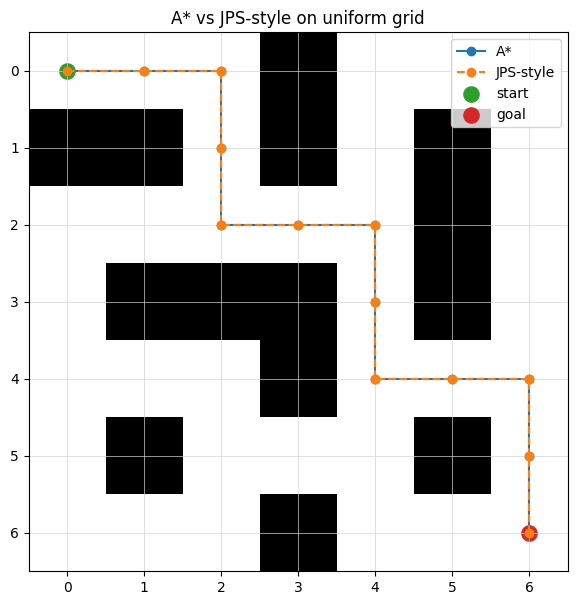

In [3]:
a_path, a_exp = a_star_grid(grid, start, goal)
j_path, j_exp = jps_style_grid(grid, start, goal)

a_plot = a_path
j_plot = densify_path(j_path)

print(f'A* path found: {a_path is not None}, expansions: {a_exp}')
print(f'JPS-style path found: {j_path is not None}, expansions: {j_exp}')

draw_compare(grid, start, goal, a_plot, j_plot, title='A* vs JPS-style on uniform grid')

## 4) Explore Interactively

Switch maps to see where JPS-style pruning helps most.
Long corridors and open regions usually show larger expansion differences.

In [4]:
map_cases = {
    'Corridor': {
        'grid': np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [1, 1, 0, 1, 0, 1, 0],
            [0, 0, 0, 0, 0, 1, 0],
            [0, 1, 1, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
    'Open': {
        'grid': np.array([
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
    'Blocked': {
        'grid': np.array([
            [0, 0, 0, 1, 0, 0, 0],
            [1, 1, 0, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 1, 0],
            [0, 1, 1, 1, 0, 1, 0],
            [0, 0, 0, 1, 0, 0, 0],
            [0, 1, 0, 0, 0, 1, 1],
            [0, 0, 0, 1, 0, 1, 0],
        ], dtype=int),
        'start': (0, 0),
        'goal': (6, 6),
    },
}

map_selector = widgets.Dropdown(
    options=list(map_cases.keys()),
    value='Corridor',
    description='Map',
)
output = widgets.Output()

def update_view(*_args):
    case = map_cases[map_selector.value]
    grid_local = case['grid']
    start_local = case['start']
    goal_local = case['goal']
    with output:
        output.clear_output(wait=True)
        a_path_local, a_exp_local = a_star_grid(grid_local, start_local, goal_local)
        j_path_local, j_exp_local = jps_style_grid(grid_local, start_local, goal_local)
        print(f'A* path found: {a_path_local is not None}, expansions: {a_exp_local}')
        print(f'JPS-style path found: {j_path_local is not None}, expansions: {j_exp_local}')
        draw_compare(grid_local, start_local, goal_local, a_path_local, densify_path(j_path_local), title='A* vs JPS-style interactive view')

map_selector.observe(update_view, names='value')
display(widgets.VBox([map_selector, output]))
update_view()